In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
sa1_path = "../data/raw/ABS/SA1_Boundary_Shapefiles/SA1_2021_AUST_GDA2020.shp"
gdf_sa1 = gpd.read_file(sa1_path)
gdf_sa1.head()

,SA1_CODE21,CHG_FLAG21,CHG_LBL21,SA2_CODE21,SA2_NAME21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,10102100701,0,No change,101021007,Braidwood,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,362.8727,http://linked.data.gov.au/dataset/asgsed3/SA1/...,"POLYGON ((149.89111 -35.08989, 149.89181 -35.0..."
1,10102100702,0,No change,101021007,Braidwood,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,229.7459,http://linked.data.gov.au/dataset/asgsed3/SA1/...,"POLYGON ((149.73421 -35.36757, 149.74475 -35.3..."
2,10102100703,0,No change,101021007,Braidwood,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,2.3910,http://linked.data.gov.au/dataset/asgsed3/SA1/...,"POLYGON ((149.77998 -35.44066, 149.77997 -35.4..."
3,10102100704,0,No change,101021007,Braidwood,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,1.2816,http://linked.data.gov.au/dataset/asgsed3/SA1/...,"POLYGON ((149.79744 -35.44148, 149.79779 -35.4..."
4,10102100705,0,No change,101021007,Braidwood,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,1.1978,http://linked.data.gov.au/dataset/asgsed3/SA1/...,"POLYGON ((149.79499 -35.44901, 149.79518 -35.4..."


In [7]:
gdf_adelaide = gdf_sa1[gdf_sa1['GCC_NAME21'] == 'Greater Adelaide'].copy()
gdf_adelaide = gdf_adelaide.to_crs(epsg=7854)
print("Current CRS:", gdf_adelaide.crs)

Current CRS: EPSG:7854


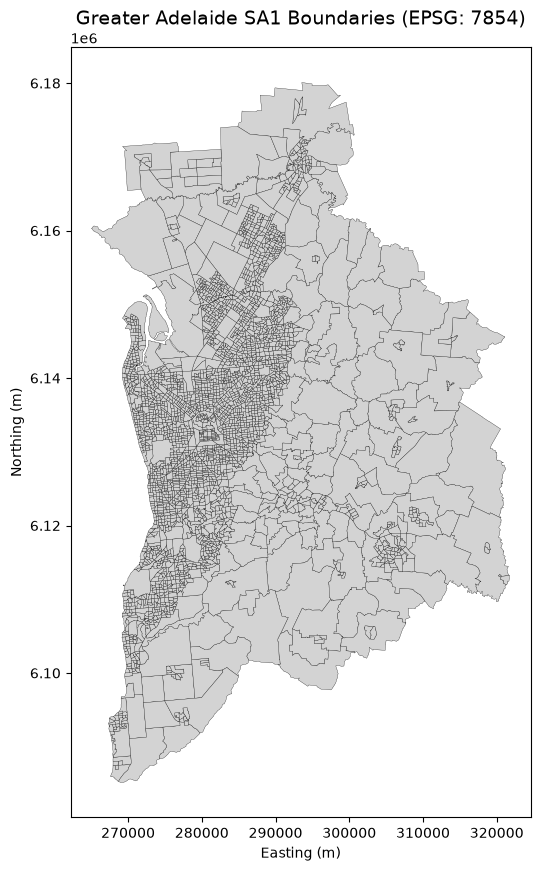

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_adelaide.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.2)
plt.title("Greater Adelaide SA1 Boundaries (EPSG: 7854)", fontsize=14)
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.show()

<Axes: >

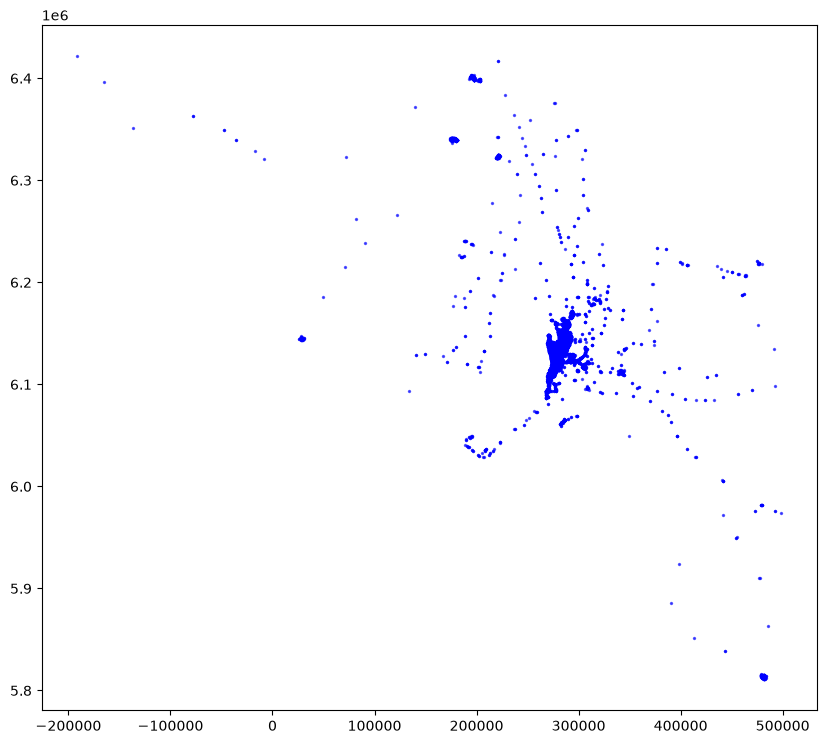

In [18]:
df = pd.read_csv("../data/raw/gtfs/stops.txt")

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat), crs="EPSG:4326")

gdf_projected = gdf.to_crs("EPSG:7854")
gdf_projected.plot(figsize=(10,10), color="blue", markersize=2, alpha=0.6)

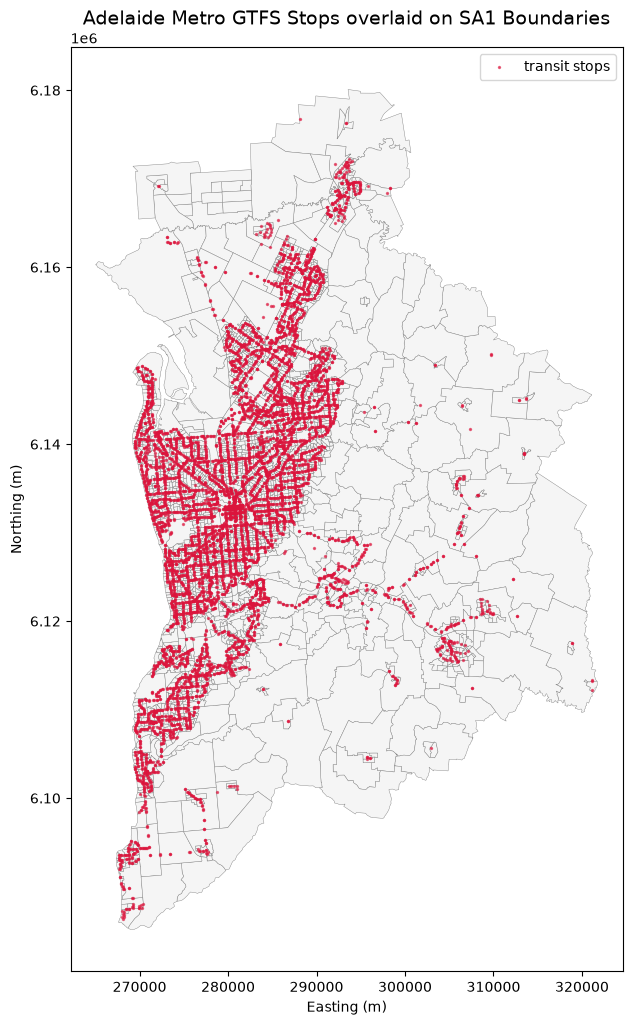

In [21]:
fig, ax = plt.subplots(figsize=(12,12))

gdf_adelaide.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.3)
#gdf_projected.plot(ax=ax, color="crimson", markersize=2, alpha=0.6, label="transit stops")

stops_adelaide = gdf_projected.clip(gdf_adelaide)
stops_adelaide.plot(ax=ax, color="crimson", markersize=2, alpha=0.6, label="transit stops")

plt.title("Adelaide Metro GTFS Stops overlaid on SA1 Boundaries", fontsize=14)
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.legend(loc="upper right")
plt.show()

In [39]:
calendar = pd.read_csv("../data/raw/gtfs/calendar.txt")
weekday_calendar = calendar[calendar["tuesday"] == 1]
valid_service_ids = weekday_calendar["service_id"]
trips = pd.read_csv("../data/raw/gtfs/trips.txt")
weekday_trips = trips[trips["service_id"].isin(valid_service_ids)]

df2 = pd.read_csv("../data/raw/gtfs/stop_times.txt", sep=",")

merged_df = pd.merge(weekday_trips, df2, on="trip_id", how="inner")
merged_df["departure_time"] = pd.to_timedelta(merged_df["departure_time"])

morning_peak_start = pd.to_timedelta("07:00:00")
morning_peak_end = pd.to_timedelta("09:00:00")
afternoon_peak_start = pd.to_timedelta("16:00:00")
afternoon_peak_end = pd.to_timedelta("18:00:00")

morning_df = merged_df[
    (merged_df["departure_time"] >= morning_peak_start)&
    (merged_df["departure_time"] <= morning_peak_end)
]

afternoon_df = merged_df[
    (merged_df["departure_time"] >= afternoon_peak_start)&
    (merged_df["departure_time"] <= afternoon_peak_end)
]

morning_counts = morning_df["stop_id"].value_counts().reset_index()
morning_counts.columns = ["stop_id", "morning_peak_trips"]

morning_counts["trips_per_hour"] = morning_counts["morning_peak_trips"] / 2
morning_counts["is_high_frequency"] = morning_counts["trips_per_hour"] >= 4

morning_counts.head()

afternoon_counts = afternoon_df["stop_id"].value_counts().reset_index()
afternoon_counts.columns = ["stop_id", "afternoon_peak_trips"]

afternoon_counts["trips_per_hour"] = afternoon_counts["afternoon_peak_trips"] / 2
afternoon_counts["is_high_frequency"] = afternoon_counts["trips_per_hour"] >= 4

afternoon_counts.head()

,stop_id,afternoon_peak_trips,trips_per_hour,is_high_frequency
0,3478,255,127.5,True
1,100083,180,90.0,True
2,3463,158,79.0,True
3,3441,158,79.0,True
4,3439,130,65.0,True


In [40]:
stops_adelaide = stops_adelaide.merge(morning_counts, on="stop_id", how="left")
stops_adelaide = stops_adelaide.merge(
    afternoon_counts[["stop_id", "afternoon_peak_trips", "is_high_frequency"]],
    on="stop_id",
    how="left",
    suffixes=("_morning", "_afternoon")
)

stops_adelaide["morning_peak_trips"] = stops_adelaide["morning_peak_trips"].fillna(0)
stops_adelaide['afternoon_peak_trips'] = stops_adelaide['afternoon_peak_trips'].fillna(0)
stops_adelaide['is_high_frequency_morning'] = stops_adelaide['is_high_frequency_morning'].fillna(False)
stops_adelaide['is_high_frequency_afternoon'] = stops_adelaide['is_high_frequency_afternoon'].fillna(False)

stops_adelaide["is_high_frequency"] = (
    stops_adelaide["is_high_frequency_morning"] | stops_adelaide["is_high_frequency_afternoon"]
)

In [44]:
gdf_adelaide.to_file("../data/processed/sa1_adelaide.geojson", driver="GeoJSON")
stops_adelaide.to_file("../data/processed/stops_adelaide.geojson", driver="GeoJSON")